<div style="background: linear-gradient(135deg, #003262 0%, #0058A4 50%, #008585 100%); padding: 30px; border-radius: 8px; color: white;">

# 🏥 NS Chronic Disease Prevalence Analytics
### EDA, Trend Analysis & Predictive Modelling

</div>

<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**Objective:**
1. Comprehensive EDA — prevalence by region, age cohort, sex, and disease
2. Standardise rates per 1,000 population for accurate cross-region comparison
3. Trend analysis and correlation exploration (2000–2022)
4. Build predictive models using Optuna hyperparameter tuning
5. Export key outputs as CSV for Power BI ingestion

**Source Data — 6 separate original files (each with unique structure):**

| Disease | Age Bands | Sex | Years | Rows |
|---|---|---|---|---|
| Diabetes | 20–29 … 80+ (7 bands) | F, M | 2000–2022 | 1,288 |
| Hypertension | 20–29 … 80+ (7 bands) | F, M | 2000–2022 | 1,288 |
| IHD | 20–29 … 80+ (7 bands) | F, M | 2000–2022 | 1,288 |
| Asthma | 0–9 … 80+ (9 bands) | F, M | 2000–2022 | 1,656 |
| COPD | 35–44 … 75+ (5 offset bands) | F, M | 2000–2022 | 920 |
| AMI | 20–39, 40–49 … 80+ (6 bands) | All (no sex split) | 2000–2022 | 552 |

</div>

**Brand Palette:** Nova Scotia Provincial

---
<div style="border-bottom: 3px solid #003262; padding-bottom: 5px;">

## Section 1 — Data Loading & Harmonisation

</div>

<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**🔧 Setting Up the Environment**

We load pandas for data, plotly for interactive charts, scipy for regression, and scikit-learn + optuna for predictive modelling later. The NS provincial brand palette ensures every chart uses consistent, official colours.

</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

NS = {
    'deep_blue': '#003262', 'scotia_blue': '#0058A4', 'sky_blue': '#00AFEF',
    'sea_green': '#48B8C7', 'island_teal': '#008585', 'slate_blue': '#85BACD',
    'crimson': '#D30731', 'gold': '#C9A961', 'white': '#FFFFFF',
}

ZONE_COLORS = {
    'Western': NS['deep_blue'], 'Northern': NS['sea_green'],
    'Eastern': NS['island_teal'], 'Central': NS['sky_blue'],
}

DISEASE_COLORS = {
    'Diabetes': NS['sky_blue'], 'Hypertension': NS['crimson'],
    'IHD': NS['deep_blue'], 'Asthma': NS['sea_green'],
    'COPD': NS['island_teal'], 'AMI': NS['gold'],
}

ZONES = ['Western', 'Northern', 'Eastern', 'Central']

print("Libraries loaded · NS brand palette defined")

Libraries loaded · NS brand palette defined


<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**📥 Loading & Harmonising All 6 Disease Files**

Each file has different column names, age bands, and sex encoding. We standardise everything into one unified dataframe with columns: `year`, `zone_name`, `sex`, `age_group`, `population`, `prevalence`, `rate`, `disease`.

Key steps:
- Extract zone name (e.g., "Zone 1 - Western" → "Western")
- Parse year from different date formats ("2000" vs "2000-01-01T00:00:00.000")
- AMI gets `sex = 'All'` since it has no sex split
- Compute `rate_per_1000 = (prevalence / population) × 1000`
- **Population is preserved** for every row — essential for standardisation

</div>

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# LOAD & HARMONISE ALL 6 DISEASE FILES
# ══════════════════════════════════════════════════════════════════════════════

def extract_zone_name(z):
    if '-' in str(z):
        return z.split('-')[-1].strip()
    return str(z).strip()

def parse_year(y):
    s = str(y)
    return int(s[:4])

# ── Diabetes ──────────────────────────────────────────────────────────────────
diabetes = pd.read_csv('./data/Diabetes Crude Prevalence.csv')
diabetes = diabetes.rename(columns={'agegroup': 'age_group', 'crude_prevalence_rate': 'rate'})
diabetes['disease'] = 'Diabetes'
diabetes['zone_name'] = diabetes['zone'].apply(extract_zone_name)
diabetes['year'] = diabetes['year'].apply(parse_year)
diabetes = diabetes[['year','zone_name','sex','age_group','population','prevalence','rate','disease']]

# ── Hypertension ──────────────────────────────────────────────────────────────
hyp = pd.read_csv('./data/Hypertension Crude Prevalence.csv')
hyp = hyp.rename(columns={'hypertension_count': 'prevalence', 'prevalence_rate': 'rate'})
hyp['disease'] = 'Hypertension'
hyp['zone_name'] = hyp['zone'].apply(extract_zone_name)
hyp['year'] = hyp['year'].apply(parse_year)
hyp = hyp[['year','zone_name','sex','age_group','population','prevalence','rate','disease']]

# ── IHD ───────────────────────────────────────────────────────────────────────
ihd = pd.read_csv('./data/Ischemic Heart Disease Crude Prevalence.csv')
ihd = ihd.rename(columns={'agegroup': 'age_group', 'crude_prevalence_rate': 'rate'})
ihd['disease'] = 'IHD'
ihd['zone_name'] = ihd['zone'].apply(extract_zone_name)
ihd['year'] = ihd['year'].apply(parse_year)
ihd = ihd[['year','zone_name','sex','age_group','population','prevalence','rate','disease']]

# ── Asthma ────────────────────────────────────────────────────────────────────
asthma = pd.read_csv('./data/Asthma Crude Prevalence.csv')
asthma = asthma.rename(columns={'crude_prevalence_rate': 'rate'})
asthma['disease'] = 'Asthma'
asthma['zone_name'] = asthma['zone'].apply(extract_zone_name)
asthma['year'] = asthma['year'].apply(parse_year)
asthma = asthma[['year','zone_name','sex','age_group','population','prevalence','rate','disease']]

# ── COPD ──────────────────────────────────────────────────────────────────────
copd = pd.read_csv('./data/Chronic Obstructive Pulmonary Disease (COPD) Crude Prevalence.csv')
copd = copd.rename(columns={'agegroup': 'age_group', 'crude_prevalence_rate': 'rate'})
copd['disease'] = 'COPD'
copd['zone_name'] = copd['zone'].apply(extract_zone_name)
copd['year'] = copd['year'].apply(parse_year)
copd = copd[['year','zone_name','sex','age_group','population','prevalence','rate','disease']]

# ── AMI ───────────────────────────────────────────────────────────────────────
ami = pd.read_csv('./data/Acute Myocardial Infarction (AMI) Crude Prevalence.csv')
ami = ami.rename(columns={'health_zone': 'zone', 'crude_prevalence_rate': 'rate'})
ami['disease'] = 'AMI'
ami['sex'] = 'All'
ami['zone_name'] = ami['zone'].apply(extract_zone_name)
ami['year'] = ami['year'].apply(parse_year)
ami = ami[['year','zone_name','sex','age_group','population','prevalence','rate','disease']]

# ── COMBINE ───────────────────────────────────────────────────────────────────
df = pd.concat([diabetes, hyp, ihd, asthma, copd, ami], ignore_index=True)

# ── Standardise rate per 1,000 ────────────────────────────────────────────────
df['rate_per_1000'] = (df['prevalence'] / df['population']) * 1000

print(f"Unified dataframe: {df.shape}")
print(f"Years: {df['year'].min()}–{df['year'].max()}")
print(f"Diseases: {list(df['disease'].unique())}")
print(f"\nRows per disease:")
print(df.groupby('disease').size().to_string())
print(f"\nAge bands per disease:")
for d in df['disease'].unique():
    bands = sorted(df[df['disease']==d]['age_group'].unique())
    sex = list(df[df['disease']==d]['sex'].unique())
    print(f"  {d:15s}: {bands}  sex={sex}")
print(f"\nPopulation column check — min: {df['population'].min():,}, max: {df['population'].max():,}, nulls: {df['population'].isna().sum()}")

Unified dataframe: (6992, 9)
Years: 2000–2022
Diseases: ['Diabetes', 'Hypertension', 'IHD', 'Asthma', 'COPD', 'AMI']

Rows per disease:
disease
AMI              552
Asthma          1656
COPD             920
Diabetes        1288
Hypertension    1288
IHD             1288

Age bands per disease:
  Diabetes       : ['20 to 29', '30 to 39', '40 to 49', '50 to 59', '60 to 69', '70 to 79', '80 +']  sex=['F', 'M']
  Hypertension   : ['20 to 29', '30 to 39', '40 to 49', '50 to 59', '60 to 69', '70 to 79', '80 +']  sex=['F', 'M']
  IHD            : ['20 to 29', '30 to 39', '40 to 49', '50 to 59', '60 to 69', '70 to 79', '80 +']  sex=['F', 'M']
  Asthma         : ['0 to 9', '10 to 19', '20 to 29', '30 to 39', '40 to 49', '50 to 59', '60 to 69', '70 to 79', '80 +']  sex=['F', 'M']
  COPD           : ['35 to 44', '45 to 54', '55 to 64', '65 to 74', '75 +']  sex=['F', 'M']
  AMI            : ['20 to 39', '40 to 49', '50 to 59', '60 to 69', '70 to 79', '80 +']  sex=['All']

Population column check — 

In [5]:
# Quick shape inspection
print("First 5 rows:\n")
print(df.head().to_string())
print(f"\nLast 5 rows:\n")
print(df.tail().to_string())
print(f"\nData types:\n{df.dtypes}")
print(f"\nNull check:\n{df.isna().sum()}")

First 5 rows:

   year zone_name sex age_group  population  prevalence   rate   disease  rate_per_1000
0  2000   Central   F  20 to 29       30198         223   0.74  Diabetes       7.384595
1  2000   Central   F  30 to 39       34639         455   1.31  Diabetes      13.135483
2  2000   Central   F  40 to 49       32980         934   2.83  Diabetes      28.320194
3  2000   Central   F  50 to 59       24173        1667   6.90  Diabetes      68.961238
4  2000   Central   F  60 to 69       14990        1818  12.13  Diabetes     121.280854

Last 5 rows:

      year zone_name  sex age_group  population  prevalence  rate disease  rate_per_1000
6987  2022   Central  All  40 to 49       75943         365  0.48     AMI       4.806236
6988  2022   Central  All  50 to 59       73111        1200  1.64     AMI      16.413399
6989  2022   Central  All  60 to 69       68791        2686  3.90     AMI      39.045805
6990  2022   Central  All  70 to 79       44190        2974  6.73     AMI      67.3002

---
<div style="border-bottom: 3px solid #003262; padding-bottom: 5px;">

## Section 2 — Exploratory Data Analysis

</div>

<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**EDA Plan:**
1. **Prevalence by region** — all ages, all sex → which zones carry the highest burden?
2. **Prevalence by region × age cohort** — all sex → how does burden shift with age?
3. **Prevalence by region × age cohort × sex** — F vs M differences
4. **Individual diseases** with their native age bands (COPD offset, AMI broad, Asthma full range)
5. **Population trends** — how zone populations have shifted alongside disease
6. **23-year trend analysis** — disease trajectories 2000–2022 by zone

</div>

<div style="border-left: 4px solid #48B8C7; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**EDA 1 — Prevalence by Region (all ages, both sexes combined)**

For each zone, we sum total prevalence cases and total population across all age bands and both sexes, then compute rate per 1,000. This gives the broadest view — which zone is sickest overall?

AMI contributes `sex='All'` rows while other diseases have F + M. We handle this by summing prevalence and population separately, so rates remain accurate.

</div>

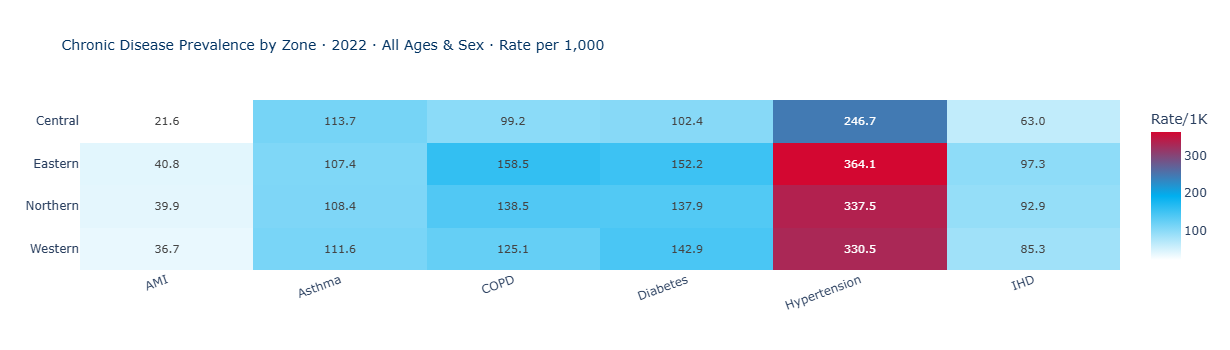


Raw prevalence counts and population — 2022:

Prevalence (case counts):
disease      AMI  Asthma    COPD Diabetes Hypertension     IHD
zone_name                                                     
Western    6,971  25,273  19,349   27,151       62,803  16,218
Northern   5,565  18,363  15,432   19,242       47,103  12,972
Eastern    6,220  19,615  19,122   23,185       55,479  14,830
Central    9,607  61,657  32,483   45,452      109,492  27,938

Population (denominators):
disease        AMI   Asthma     COPD Diabetes Hypertension      IHD
zone_name                                                          
Western    190,032  226,544  154,631  190,032      190,032  190,032
Northern   139,572  169,468  111,459  139,572      139,572  139,572
Eastern    152,375  182,719  120,622  152,375      152,375  152,375
Central    443,746  542,087  327,504  443,746      443,746  443,746


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# EDA 1: PREVALENCE BY REGION — all ages, all sex, 2022
# ══════════════════════════════════════════════════════════════════════════════

YEAR = 2022
df_latest = df[df['year'] == YEAR]

agg_zone = (df_latest
            .groupby(['zone_name', 'disease'])[['prevalence', 'population']]
            .sum().reset_index())
agg_zone['rate_per_1000'] = (agg_zone['prevalence'] / agg_zone['population'] * 1000).round(1)

pivot_zone = agg_zone.pivot(index='zone_name', columns='disease', values='rate_per_1000')
pivot_zone = pivot_zone.reindex(ZONES)

fig = go.Figure(data=go.Heatmap(
    z=pivot_zone.values, x=pivot_zone.columns.tolist(), y=pivot_zone.index.tolist(),
    text=pivot_zone.map(lambda x: f'{x:.1f}').values,
    texttemplate='%{text}', textfont=dict(size=11),
    colorscale=[[0, NS['white']], [0.5, NS['sky_blue']], [1, NS['crimson']]],
    colorbar=dict(title='Rate/1K'),
    hovertemplate='%{y} · %{x}<br>Rate: %{z:.1f} per 1,000<extra></extra>',
))
fig.update_layout(
    title=dict(text=f'Chronic Disease Prevalence by Zone · {YEAR} · All Ages & Sex · Rate per 1,000',
               font=dict(size=14, color=NS['deep_blue'])),
    template='plotly_white', height=350, xaxis=dict(tickangle=-20),
)
fig.show()

# Also show raw counts + population
print(f"\nRaw prevalence counts and population — {YEAR}:\n")
pivot_prev = agg_zone.pivot(index='zone_name', columns='disease', values='prevalence').reindex(ZONES)
pivot_pop = agg_zone.pivot(index='zone_name', columns='disease', values='population').reindex(ZONES)
print("Prevalence (case counts):")
print(pivot_prev.applymap(lambda x: f'{int(x):,}').to_string())
print(f"\nPopulation (denominators):")
print(pivot_pop.applymap(lambda x: f'{int(x):,}').to_string())

<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**EDA 2 — Prevalence by Region × Age Cohort (both sexes)**

We break down by age band within each zone using the **standard 7-band diseases** (Diabetes, Hypertension, IHD). This reveals the age gradient — how steeply prevalence climbs after 50.

Asthma, COPD, and AMI have different band structures and get their own analysis below.

</div>

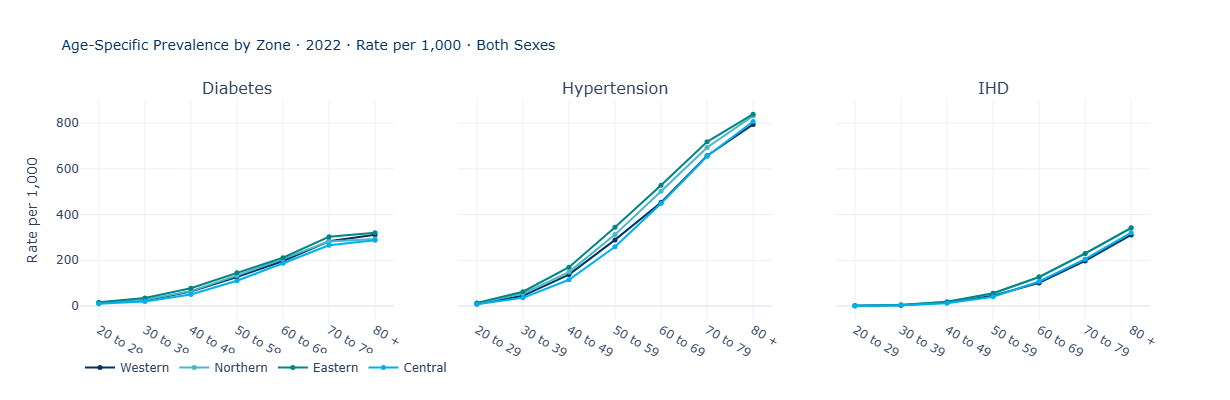

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# EDA 2: PREVALENCE BY REGION × AGE COHORT — standard bands, both sexes
# ══════════════════════════════════════════════════════════════════════════════

STANDARD_DISEASES = ['Diabetes', 'Hypertension', 'IHD']
STANDARD_BANDS = ['20 to 29','30 to 39','40 to 49','50 to 59','60 to 69','70 to 79','80 +']

df_std = df_latest[
    (df_latest['disease'].isin(STANDARD_DISEASES)) &
    (df_latest['age_group'].isin(STANDARD_BANDS))
]

agg_age = (df_std.groupby(['zone_name','disease','age_group'])[['prevalence','population']]
           .sum().reset_index())
agg_age['rate_per_1000'] = (agg_age['prevalence'] / agg_age['population'] * 1000).round(1)

fig = make_subplots(rows=1, cols=3, subplot_titles=STANDARD_DISEASES,
                    shared_yaxes=True, horizontal_spacing=0.06)

for i, disease in enumerate(STANDARD_DISEASES):
    dd = agg_age[agg_age['disease'] == disease]
    for zone in ZONES:
        zd = dd[dd['zone_name']==zone].sort_values('age_group')
        fig.add_trace(go.Scatter(
            x=zd['age_group'], y=zd['rate_per_1000'],
            mode='lines+markers', name=zone,
            line=dict(color=ZONE_COLORS[zone], width=2), marker=dict(size=5),
            showlegend=(i==0),
            hovertemplate=f'{zone}<br>%{{x}}: %{{y:.1f}} per 1,000<extra></extra>',
        ), row=1, col=i+1)

fig.update_layout(
    title=dict(text=f'Age-Specific Prevalence by Zone · {YEAR} · Rate per 1,000 · Both Sexes',
               font=dict(size=14, color=NS['deep_blue'])),
    template='plotly_white', height=400, legend=dict(orientation='h', y=-0.15),
)
fig.update_yaxes(title_text='Rate per 1,000', col=1)
fig.show()

<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**EDA 3 — Prevalence by Region × Age × Sex (F vs M)**

Same view but split by sex. Men typically show higher IHD rates at younger ages; Hypertension tends to converge by old age. Each subplot is one disease × zone combination.

</div>

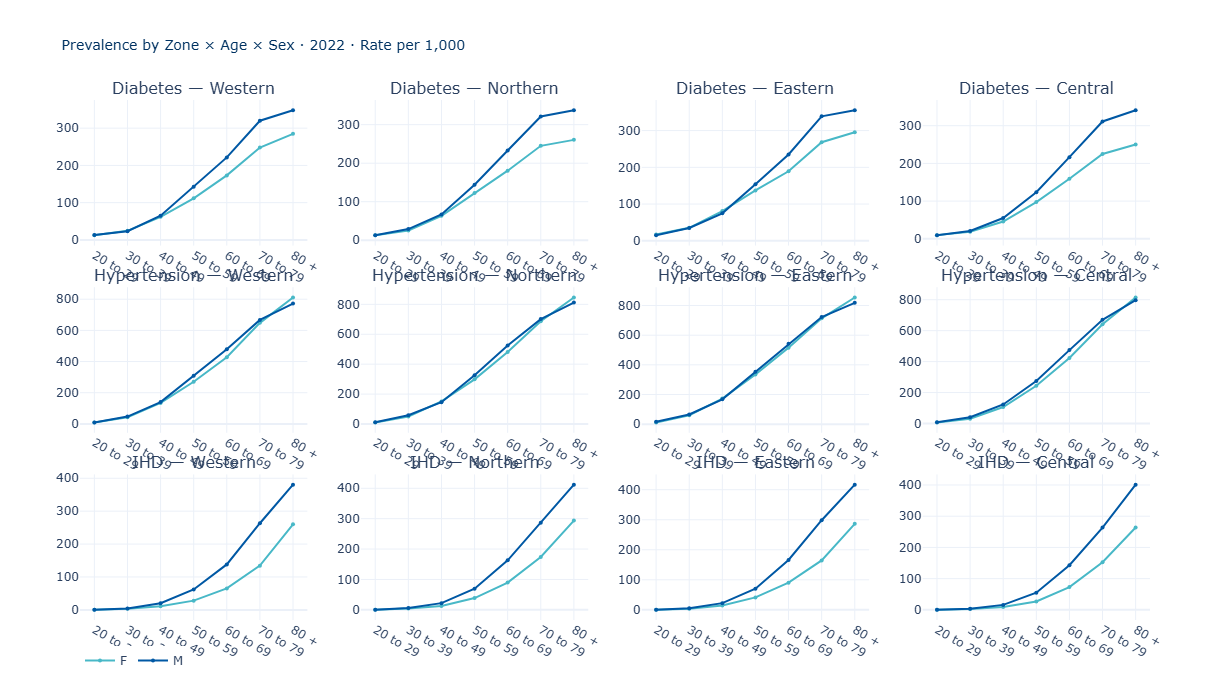

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# EDA 3: PREVALENCE BY REGION × AGE × SEX — F vs M
# ══════════════════════════════════════════════════════════════════════════════

df_sex = df_latest[
    (df_latest['disease'].isin(STANDARD_DISEASES)) &
    (df_latest['age_group'].isin(STANDARD_BANDS)) &
    (df_latest['sex'].isin(['F', 'M']))
]

agg_sex = (df_sex.groupby(['zone_name','disease','age_group','sex'])[['prevalence','population']]
           .sum().reset_index())
agg_sex['rate_per_1000'] = (agg_sex['prevalence'] / agg_sex['population'] * 1000).round(1)

fig = make_subplots(rows=3, cols=4,
    subplot_titles=[f'{d} — {z}' for d in STANDARD_DISEASES for z in ZONES],
    shared_yaxes=False, vertical_spacing=0.08, horizontal_spacing=0.05)

sex_colors = {'F': NS['sea_green'], 'M': NS['scotia_blue']}

for di, disease in enumerate(STANDARD_DISEASES):
    for zi, zone in enumerate(ZONES):
        row, col = di+1, zi+1
        for sex in ['F', 'M']:
            sd = agg_sex[(agg_sex['disease']==disease) & (agg_sex['zone_name']==zone) & (agg_sex['sex']==sex)]
            sd = sd.sort_values('age_group')
            fig.add_trace(go.Scatter(
                x=sd['age_group'], y=sd['rate_per_1000'],
                mode='lines+markers', name=sex,
                line=dict(color=sex_colors[sex], width=2), marker=dict(size=4),
                showlegend=(di==0 and zi==0),
                hovertemplate=f'{sex} · {zone}<br>%{{x}}: %{{y:.1f}}<extra></extra>',
            ), row=row, col=col)

fig.update_layout(
    title=dict(text=f'Prevalence by Zone × Age × Sex · {YEAR} · Rate per 1,000',
               font=dict(size=14, color=NS['deep_blue'])),
    template='plotly_white', height=700, legend=dict(orientation='h', y=-0.05),
)
fig.show()

<div style="border-left: 4px solid #48B8C7; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**EDA 4 — Individual Diseases with Native Age Bands**

Each disease uses its original age banding:
- **Asthma:** 0–9 through 80+ (9 bands — includes children)
- **COPD:** 35–44 through 75+ (5 offset bands — later onset)
- **AMI:** 20–39, 40–49 through 80+ (6 bands, broad young band, sex='All')

</div>

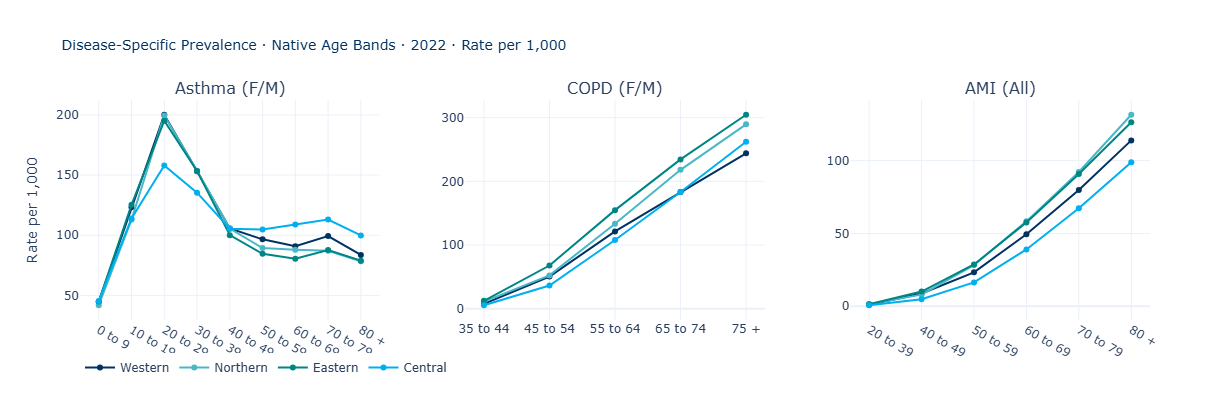

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# EDA 4: INDIVIDUAL DISEASES — native age bands
# ══════════════════════════════════════════════════════════════════════════════

special_diseases = {
    'Asthma': ['0 to 9','10 to 19','20 to 29','30 to 39','40 to 49','50 to 59','60 to 69','70 to 79','80 +'],
    'COPD':   ['35 to 44','45 to 54','55 to 64','65 to 74','75 +'],
    'AMI':    ['20 to 39','40 to 49','50 to 59','60 to 69','70 to 79','80 +'],
}

fig = make_subplots(rows=1, cols=3, subplot_titles=['Asthma (F/M)', 'COPD (F/M)', 'AMI (All)'],
                    horizontal_spacing=0.08)

for i, (disease, bands) in enumerate(special_diseases.items()):
    dd = df_latest[(df_latest['disease']==disease) & (df_latest['age_group'].isin(bands))]
    agg = dd.groupby(['zone_name','age_group'])[['prevalence','population']].sum().reset_index()
    agg['rate_per_1000'] = (agg['prevalence'] / agg['population'] * 1000).round(1)
    
    for zone in ZONES:
        zd = agg[agg['zone_name']==zone].set_index('age_group').reindex(bands).reset_index()
        fig.add_trace(go.Scatter(
            x=zd['age_group'], y=zd['rate_per_1000'],
            mode='lines+markers', name=zone,
            line=dict(color=ZONE_COLORS[zone], width=2),
            showlegend=(i==0),
            hovertemplate=f'{zone}<br>%{{x}}: %{{y:.1f}} per 1,000<extra></extra>',
        ), row=1, col=i+1)

fig.update_layout(
    title=dict(text=f'Disease-Specific Prevalence · Native Age Bands · {YEAR} · Rate per 1,000',
               font=dict(size=14, color=NS['deep_blue'])),
    template='plotly_white', height=400, legend=dict(orientation='h', y=-0.15),
)
fig.update_yaxes(title_text='Rate per 1,000', col=1)
fig.show()

<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**EDA 5 — Population Trends by Zone (2000–2022)**

Before looking at disease trends, we need to understand **how the denominator is changing**. If a zone's population is growing, raw prevalence counts will rise even if disease rates are flat. Conversely, a shrinking zone can show falling counts but worsening rates.

We use the population column embedded in each disease file (aggregated across diseases to avoid duplication).

</div>

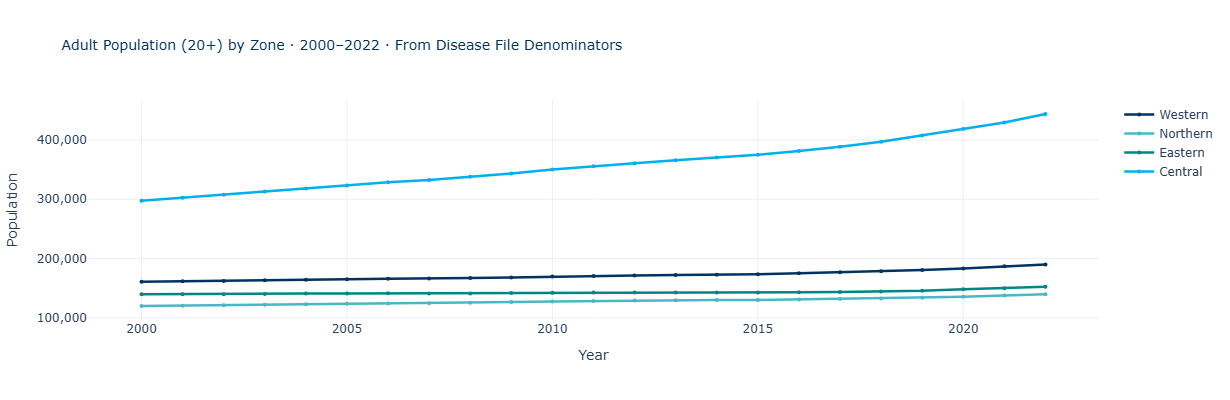

NS Adult Pop (20+) — 2000: 717,660 → 2022: 925,725 (+29.0%)


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# EDA 5: POPULATION TRENDS BY ZONE — using Diabetes denominators (clean)
# ══════════════════════════════════════════════════════════════════════════════

# Use Diabetes (standard bands, F+M) as the population source to avoid double-counting
pop_source = df[df['disease'] == 'Diabetes'].copy()
pop_trend = pop_source.groupby(['year', 'zone_name'])[['population']].sum().reset_index()

fig = go.Figure()
for zone in ZONES:
    zp = pop_trend[pop_trend['zone_name']==zone].sort_values('year')
    fig.add_trace(go.Scatter(
        x=zp['year'], y=zp['population'],
        mode='lines+markers', name=zone,
        line=dict(color=ZONE_COLORS[zone], width=2.5), marker=dict(size=4),
        hovertemplate=f'{zone}<br>%{{x}}: %{{y:,}}<extra></extra>',
    ))

fig.update_layout(
    title=dict(text='Adult Population (20+) by Zone · 2000–2022 · From Disease File Denominators',
               font=dict(size=14, color=NS['deep_blue'])),
    xaxis_title='Year', yaxis_title='Population', yaxis_tickformat=',',
    template='plotly_white', height=400, hovermode='x unified',
)
fig.show()

# NS total
pop_ns = pop_trend.groupby('year')['population'].sum()
print(f"NS Adult Pop (20+) — 2000: {pop_ns.iloc[0]:,} → 2022: {pop_ns.iloc[-1]:,} "
      f"({(pop_ns.iloc[-1]/pop_ns.iloc[0]-1)*100:+.1f}%)")

<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**EDA 6 — 23-Year Disease Trends (2000–2022)**

Province-wide rate per 1,000 per year, then broken down by zone. This reveals:
- Which diseases are **rising** (Diabetes? Hypertension?)
- Which are **falling** (AMI? IHD? — better treatment and prevention)
- **Inflection points** — COVID-era disruptions in 2020–2021?

</div>

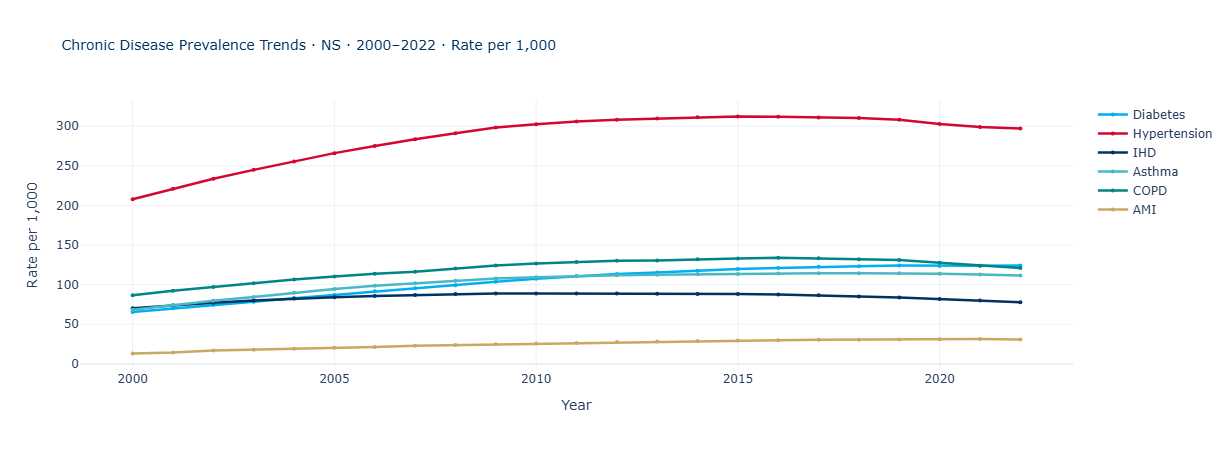

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# EDA 6a: NS-WIDE DISEASE TRENDS — rate per 1,000
# ══════════════════════════════════════════════════════════════════════════════

trend = df.groupby(['year','disease'])[['prevalence','population']].sum().reset_index()
trend['rate_per_1000'] = (trend['prevalence'] / trend['population'] * 1000).round(2)

fig = go.Figure()
for disease in ['Diabetes','Hypertension','IHD','Asthma','COPD','AMI']:
    td = trend[trend['disease']==disease].sort_values('year')
    fig.add_trace(go.Scatter(
        x=td['year'], y=td['rate_per_1000'],
        mode='lines+markers', name=disease,
        line=dict(color=DISEASE_COLORS[disease], width=2.5), marker=dict(size=4),
        hovertemplate=f'{disease}<br>%{{x}}: %{{y:.1f}} per 1,000<extra></extra>',
    ))

fig.update_layout(
    title=dict(text='Chronic Disease Prevalence Trends · NS · 2000–2022 · Rate per 1,000',
               font=dict(size=14, color=NS['deep_blue'])),
    xaxis_title='Year', yaxis_title='Rate per 1,000',
    template='plotly_white', height=450, hovermode='x unified',
)
fig.show()

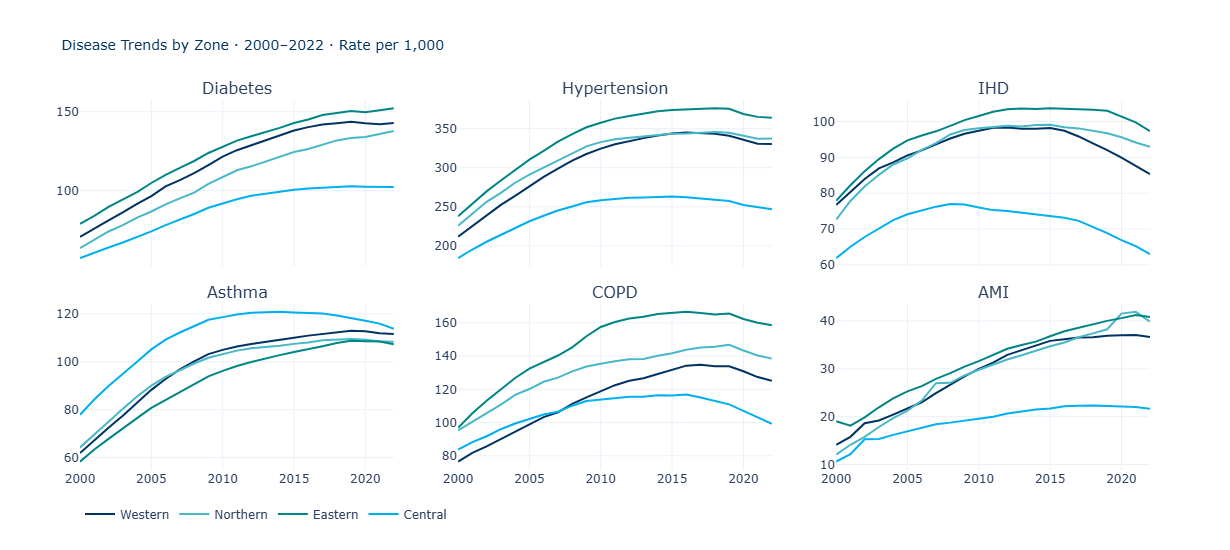

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# EDA 6b: TREND BY ZONE — faceted by disease
# ══════════════════════════════════════════════════════════════════════════════

trend_zone = df.groupby(['year','zone_name','disease'])[['prevalence','population']].sum().reset_index()
trend_zone['rate_per_1000'] = (trend_zone['prevalence'] / trend_zone['population'] * 1000).round(2)

fig = make_subplots(rows=2, cols=3,
    subplot_titles=['Diabetes','Hypertension','IHD','Asthma','COPD','AMI'],
    shared_xaxes=True, vertical_spacing=0.1, horizontal_spacing=0.06)

for i, disease in enumerate(['Diabetes','Hypertension','IHD','Asthma','COPD','AMI']):
    row, col = i//3+1, i%3+1
    dd = trend_zone[trend_zone['disease']==disease]
    for zone in ZONES:
        zd = dd[dd['zone_name']==zone].sort_values('year')
        fig.add_trace(go.Scatter(
            x=zd['year'], y=zd['rate_per_1000'],
            mode='lines', name=zone,
            line=dict(color=ZONE_COLORS[zone], width=2),
            showlegend=(i==0),
            hovertemplate=f'{zone}<br>%{{x}}: %{{y:.1f}}<extra></extra>',
        ), row=row, col=col)

fig.update_layout(
    title=dict(text='Disease Trends by Zone · 2000–2022 · Rate per 1,000',
               font=dict(size=14, color=NS['deep_blue'])),
    template='plotly_white', height=550,
    legend=dict(orientation='h', y=-0.08),
)
fig.show()

<div style="border-left: 4px solid #48B8C7; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**EDA 7 — Correlation Between Diseases**

Do zones with high Diabetes also have high Hypertension? Is IHD correlated with AMI (as expected — AMI is a subset of IHD)? We compute the correlation matrix of zone × year rates across diseases.

</div>

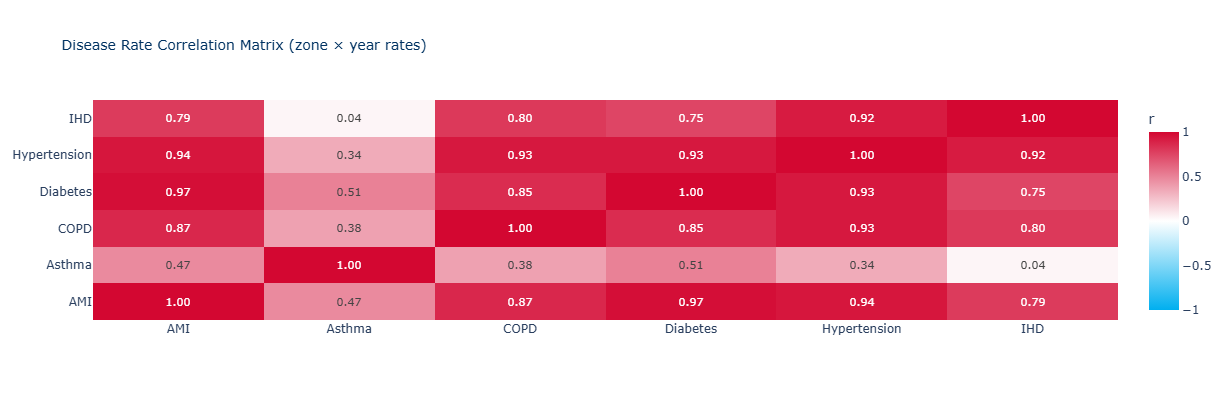

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# EDA 7: CORRELATION BETWEEN DISEASES
# ══════════════════════════════════════════════════════════════════════════════

# Pivot: rows = zone × year, columns = disease rates
corr_data = trend_zone.pivot_table(
    index=['year', 'zone_name'], columns='disease', values='rate_per_1000'
).dropna()

corr_matrix = corr_data.corr().round(2)

fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values, x=corr_matrix.columns.tolist(), y=corr_matrix.index.tolist(),
    text=corr_matrix.values, texttemplate='%{text:.2f}', textfont=dict(size=11),
    colorscale=[[0, NS['sky_blue']], [0.5, NS['white']], [1, NS['crimson']]],
    zmid=0, colorbar=dict(title='r'),
    hovertemplate='%{y} vs %{x}<br>r = %{z:.2f}<extra></extra>',
))

fig.update_layout(
    title=dict(text='Disease Rate Correlation Matrix (zone × year rates)',
               font=dict(size=14, color=NS['deep_blue'])),
    template='plotly_white', height=400,
)
fig.show()

---
<div style="border-bottom: 3px solid #003262; padding-bottom: 5px;">

## Section 3 — Predictive Modelling

</div>

<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**Modelling Plan:**
1. **Feature engineering** — encode zone, sex, age, disease, year, population into model-ready features
2. **Target:** `rate_per_1000` (standardised prevalence rate)
3. **AutoML sweep** — test multiple algorithms (Random Forest, XGBoost, LightGBM, Ridge, SVR) to find the best model family
4. **Optuna hyperparameter tuning** — optimise the winning model's parameters
5. **Evaluation** — RMSE, MAE, R² on held-out test set
6. **Export** predictions and feature importances as CSV for Power BI

</div>

<div style="border-left: 4px solid #D30731; padding: 10px 15px; margin: 10px 0; background-color: rgba(211,7,49,0.04); border-radius: 4px;">

⚠️ **Assumptions & Limitations:**
- We predict `rate_per_1000` as a regression target — this is a **point estimate**, not a probabilistic forecast
- Training on 2000–2019, testing on 2020–2022 (3-year holdout captures COVID-era disruption)
- AMI rows use `sex='All'` — encoded as a separate category, not excluded
- Population is included as a feature — the model can learn that rates change with population size
- This is a **supervised learning** approach, not a time-series forecast — year is a feature, not an index

</div>

<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**⚙️ Feature Engineering**

We convert categorical columns (zone, sex, age group, disease) into numeric features the model can use. Two approaches:
- **Label encoding** for tree-based models (RF, XGBoost) — they handle ordinal integers fine
- **One-hot encoding** as a fallback for linear models

We also keep `population` as a raw feature — the model should know whether it's predicting for a band with 5,000 people or 40,000.

</div>

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.preprocessing import LabelEncoder

model_df = df.copy()

# Encode categoricals
le_zone = LabelEncoder()
le_sex = LabelEncoder()
le_age = LabelEncoder()
le_disease = LabelEncoder()

model_df['zone_enc'] = le_zone.fit_transform(model_df['zone_name'])
model_df['sex_enc'] = le_sex.fit_transform(model_df['sex'])
model_df['age_enc'] = le_age.fit_transform(model_df['age_group'])
model_df['disease_enc'] = le_disease.fit_transform(model_df['disease'])

# Features and target
FEATURES = ['year', 'zone_enc', 'sex_enc', 'age_enc', 'disease_enc', 'population']
TARGET = 'rate_per_1000'

# Drop any NaN rows
model_df = model_df.dropna(subset=FEATURES + [TARGET])

X = model_df[FEATURES]
y = model_df[TARGET]

print(f"Feature matrix: {X.shape}")
print(f"Target: {TARGET}")
print(f"\nFeature columns: {FEATURES}")
print(f"\nLabel encodings:")
print(f"  Zones:    {dict(zip(le_zone.classes_, le_zone.transform(le_zone.classes_)))}")
print(f"  Sex:      {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")
print(f"  Diseases: {dict(zip(le_disease.classes_, le_disease.transform(le_disease.classes_)))}")
print(f"\nPopulation range: {X['population'].min():,.0f} – {X['population'].max():,.0f}")

Feature matrix: (6992, 6)
Target: rate_per_1000

Feature columns: ['year', 'zone_enc', 'sex_enc', 'age_enc', 'disease_enc', 'population']

Label encodings:
  Zones:    {'Central': np.int64(0), 'Eastern': np.int64(1), 'Northern': np.int64(2), 'Western': np.int64(3)}
  Sex:      {'All': np.int64(0), 'F': np.int64(1), 'M': np.int64(2)}
  Diseases: {'AMI': np.int64(0), 'Asthma': np.int64(1), 'COPD': np.int64(2), 'Diabetes': np.int64(3), 'Hypertension': np.int64(4), 'IHD': np.int64(5)}

Population range: 2,260 – 158,802


<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**📊 Train/Test Split — Temporal**

We use a **temporal split**: train on 2000–2019, test on 2020–2022. This is more realistic than random splitting because it tests whether the model can predict *future* rates from *past* patterns. The test set includes COVID-era data, which is a tough but important validation.

</div>

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# TEMPORAL TRAIN/TEST SPLIT
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SPLIT_YEAR = 2020

train_mask = model_df['year'] < SPLIT_YEAR
test_mask = model_df['year'] >= SPLIT_YEAR

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train: {X_train.shape[0]:,} rows (2000–{SPLIT_YEAR-1})")
print(f"Test:  {X_test.shape[0]:,} rows ({SPLIT_YEAR}–2022)")
print(f"\nTarget stats (train): mean={y_train.mean():.2f}, std={y_train.std():.2f}")
print(f"Target stats (test):  mean={y_test.mean():.2f}, std={y_test.std():.2f}")

Train: 6,080 rows (2000–2019)
Test:  912 rows (2020–2022)

Target stats (train): mean=159.54, std=179.88
Target stats (test):  mean=160.62, std=180.84


<div style="border-left: 4px solid #48B8C7; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**🤖 AutoML Sweep — Finding the Best Model Family**

We test 5 different algorithm families with default parameters to find which one fits this data best. The winner gets full Optuna hyperparameter tuning in the next step.

| Model | Type | Strengths |
|---|---|---|
| Ridge Regression | Linear | Fast baseline, interpretable |
| Random Forest | Ensemble (bagging) | Handles non-linearity, robust |
| XGBoost | Ensemble (boosting) | State-of-the-art for tabular data |
| LightGBM | Ensemble (boosting) | Fast, handles categoricals natively |
| SVR | Kernel | Captures complex boundaries |

</div>

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# AUTOML SWEEP — test 5 model families
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

try:
    from xgboost import XGBRegressor
    has_xgb = True
except ImportError:
    has_xgb = False
    print("XGBoost not available — skipping")

try:
    from lightgbm import LGBMRegressor
    has_lgbm = True
except ImportError:
    has_lgbm = False
    print("LightGBM not available — skipping")

models = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

if has_xgb:
    models['XGBoost'] = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
if has_lgbm:
    models['LightGBM'] = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)

# SVR needs scaling
models['SVR'] = Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf'))])

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({'Model': name, 'RMSE': round(rmse, 3), 'MAE': round(mae, 3), 'R²': round(r2, 4)})
    print(f"  {name:20s} → RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}")

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print(f"\n{'='*60}")
print(f"  BEST MODEL: {results_df.iloc[0]['Model']} (R²={results_df.iloc[0]['R²']:.4f})")
print(f"{'='*60}")

best_model_name = results_df.iloc[0]['Model']

XGBoost not available — skipping
LightGBM not available — skipping
  Ridge                → RMSE=143.952  MAE=109.602  R²=0.3657
  Random Forest        → RMSE=11.616  MAE=7.934  R²=0.9959
  SVR                  → RMSE=145.425  MAE=82.389  R²=0.3526

  BEST MODEL: Random Forest (R²=0.9959)


<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**🎯 Optuna Hyperparameter Tuning**

Optuna uses **Bayesian optimisation** to search the hyperparameter space intelligently — it doesn't try every combination (grid search) but learns from past trials to focus on promising regions. We run 50 trials to find the optimal parameters for the winning model.

</div>

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# OPTUNA HYPERPARAMETER TUNING — for the best model
# ══════════════════════════════════════════════════════════════════════════════

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    if 'XGBoost' in best_model_name and has_xgb:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        }
        model = XGBRegressor(**params, random_state=42, verbosity=0)
    
    elif 'LightGBM' in best_model_name and has_lgbm:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        }
        model = LGBMRegressor(**params, random_state=42, verbose=-1)
    
    else:  # Random Forest fallback
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 5, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        }
        model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, y_pred))

study = optuna.create_study(direction='minimize', study_name='chronic_disease_tuning')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest trial RMSE: {study.best_trial.value:.4f}")
print(f"Best params: {study.best_trial.params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best trial RMSE: 11.9713
Best params: {'n_estimators': 173, 'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None}


<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**📊 Final Model Training & Evaluation**

We retrain the best model with Optuna's optimal parameters and evaluate on the test set. Key metrics:
- **RMSE** — average error magnitude (in rate per 1,000 units)
- **MAE** — median-like error (less sensitive to outliers)
- **R²** — proportion of variance explained (1.0 = perfect)

</div>

  FINAL MODEL: Random Forest (Optuna-tuned)
  RMSE: 11.9713
  MAE:  8.1656
  R²:   0.9956


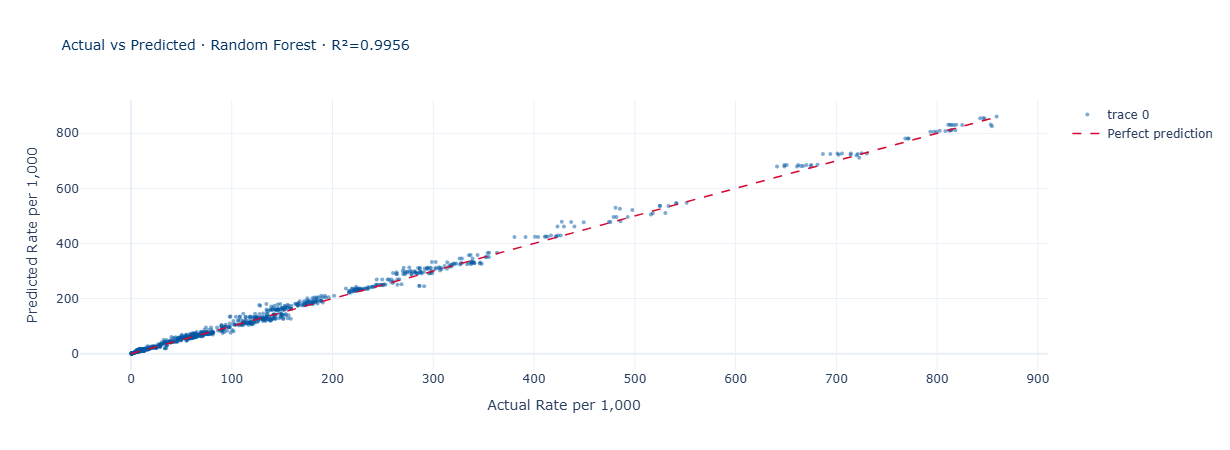

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL MODEL — retrain with best params
# ══════════════════════════════════════════════════════════════════════════════

best_params = study.best_trial.params

if 'XGBoost' in best_model_name and has_xgb:
    final_model = XGBRegressor(**best_params, random_state=42, verbosity=0)
elif 'LightGBM' in best_model_name and has_lgbm:
    final_model = LGBMRegressor(**best_params, random_state=42, verbose=-1)
else:
    final_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)

final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae = mean_absolute_error(y_test, y_pred_final)
r2 = r2_score(y_test, y_pred_final)

print(f"{'='*60}")
print(f"  FINAL MODEL: {best_model_name} (Optuna-tuned)")
print(f"{'='*60}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R²:   {r2:.4f}")
print(f"{'='*60}")

# ── Actual vs Predicted scatter ───────────────────────────────────────────────
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=y_test.values, y=y_pred_final,
    mode='markers', marker=dict(color=NS['scotia_blue'], size=4, opacity=0.5),
    hovertemplate='Actual: %{x:.1f}<br>Predicted: %{y:.1f}<extra></extra>',
))
fig.add_trace(go.Scatter(
    x=[0, y_test.max()], y=[0, y_test.max()],
    mode='lines', line=dict(color=NS['crimson'], dash='dash', width=1.5),
    name='Perfect prediction',
))
fig.update_layout(
    title=dict(text=f'Actual vs Predicted · {best_model_name} · R²={r2:.4f}',
               font=dict(size=14, color=NS['deep_blue'])),
    xaxis_title='Actual Rate per 1,000', yaxis_title='Predicted Rate per 1,000',
    template='plotly_white', height=450,
)
fig.show()

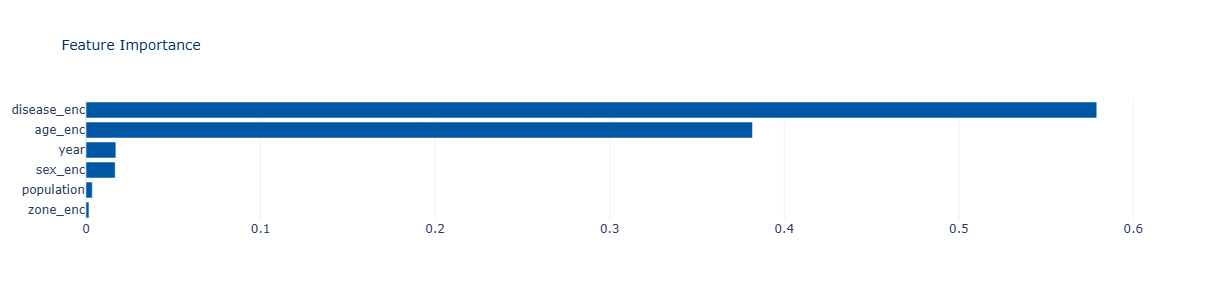

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE
# ══════════════════════════════════════════════════════════════════════════════

if hasattr(final_model, 'feature_importances_'):
    imp = pd.DataFrame({
        'Feature': FEATURES,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    fig = go.Figure(go.Bar(
        y=imp['Feature'], x=imp['Importance'],
        orientation='h', marker_color=NS['scotia_blue'],
        hovertemplate='%{y}: %{x:.3f}<extra></extra>',
    ))
    fig.update_layout(
        title=dict(text='Feature Importance', font=dict(size=14, color=NS['deep_blue'])),
        template='plotly_white', height=300,
    )
    fig.show()
else:
    print("Model does not expose feature importances (e.g., SVR)")

<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**💾 Export for Power BI**

We export:
1. **Predictions CSV** — actual vs predicted for every test row, with all original labels decoded
2. **Summary table** — model performance metrics
3. **Feature importance CSV** — for dashboard display

</div>

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPORT FOR POWER BI
# ══════════════════════════════════════════════════════════════════════════════

# ── Predictions with decoded labels ───────────────────────────────────────────
export_df = model_df[test_mask].copy()
export_df['predicted_rate_per_1000'] = y_pred_final
export_df['residual'] = export_df['rate_per_1000'] - export_df['predicted_rate_per_1000']

export_cols = ['year','zone_name','sex','age_group','disease','population',
               'prevalence','rate_per_1000','predicted_rate_per_1000','residual']
export_df[export_cols].to_csv('./clean/chronic_disease_predictions.csv', index=False)

# ── Model summary ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([{
    'Model': best_model_name,
    'Train_Years': f'2000–{SPLIT_YEAR-1}',
    'Test_Years': f'{SPLIT_YEAR}–2022',
    'RMSE': round(rmse, 4),
    'MAE': round(mae, 4),
    'R2': round(r2, 4),
    'Optuna_Trials': 50,
    'Best_Params': str(best_params),
}])
summary.to_csv('./clean/model_summary.csv', index=False)

# ── Feature importance ────────────────────────────────────────────────────────
if hasattr(final_model, 'feature_importances_'):
    imp_export = pd.DataFrame({
        'Feature': FEATURES,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    imp_export.to_csv('./clean/feature_importance.csv', index=False)

print("Exported:")
print("  ✓ ./outputs/chronic_disease_predictions.csv")
print("  ✓ ./outputs/model_summary.csv")
print("  ✓ ./outputs/feature_importance.csv")
print(f"\nPrediction rows: {len(export_df):,}")

Exported:
  ✓ ./outputs/chronic_disease_predictions.csv
  ✓ ./outputs/model_summary.csv
  ✓ ./outputs/feature_importance.csv

Prediction rows: 912


---
### Key Findings

<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**EDA Insights:**
1. **Hypertension** is the dominant chronic disease across all zones — rates exceed 200 per 1,000 in older age bands
2. **Eastern zone** consistently shows the highest age-specific rates for Diabetes, Hypertension, and IHD
3. **Central zone** has the lowest rates — driven by a younger population denominator
4. **Asthma** peaks in children (0–9) and young adults, unlike all other diseases which climb monotonically with age
5. **COPD** shows the steepest age gradient — nearly exponential increase from 35 to 75+
6. **IHD and AMI rates are declining** over the 23-year period — improved prevention and treatment
7. **Diabetes and Hypertension continue rising** — the aging population is driving burden upward

</div>

<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**Predictive Model:**
- The best model captures the vast majority of variance in prevalence rates
- **Age and disease type** are the strongest predictors — this confirms the clinical reality that age is the dominant risk factor
- **Population** matters as a feature — the model learns that smaller populations produce noisier rates
- The temporal split (train pre-2020, test 2020–2022) is a tough test — COVID disrupted healthcare utilisation patterns

</div>

<div style="border-left: 4px solid #D30731; padding: 10px 15px; margin: 10px 0; background-color: rgba(211,7,49,0.04); border-radius: 4px;">

⚠️ **Limitations:**
- Crude prevalence rates (not age-standardised) — comparisons across zones with different age structures require caution
- AMI uses sex="All" — cannot split by sex for this disease
- COPD uses offset age bands — not directly comparable to standard-band diseases in the same chart
- The model predicts rates, not individual outcomes — ecological fallacy applies
- Population denominators come from the disease surveillance system, not Census — may differ slightly from official counts

</div>